Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below:

In [1]:
NAME = "Christina Ravichandran"
COLLABORATORS = "Christina Ravichandran"

---

# Assignment - Simon's Algorithm

The places where you have enter code are marked with `# YOUR CODE HERE`.

### Question 1 (3 points)

Complete the function `initialize_simon` that creates a quantum circuit consisting of two quantum registers and a classical register for solving Simon's problem.

The function `initialize_simon` has

- Input: $n$ such that you are given a function $f:\{0,1\}^n \rightarrow \{0,1\}^n$
- Returns: A `QuantumCircuit` object with two quantum registers and a classical register with the correct number of qubits and bits respectively.

In [2]:
from qiskit import QuantumRegister, ClassicalRegister

def initialize_simon(n):
    # Do not modify anything above this line
    # YOUR CODE HERE
    qr1 = QuantumRegister(n, 'input')
    qr2 = QuantumRegister(n, 'output')
    cr = ClassicalRegister(n, 'c')
    qc = QuantumCircuit(qr1, qr2, cr)
    # Do not modify anything below this line  
    return qc

You can use the following cell to test your function.

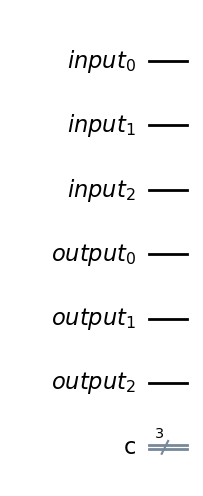

In [3]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

qc = initialize_simon(3)
qc.draw(output='mpl')

### Question 2 (4 points)

Function `simon(n)` returns a single bitstring of length $n$, as a result of running Simon's algorithm. Complete the function `get_y_list` that calls the function `simon()` until $n-1$ bitstrings are found other than the 0 string. 

The function `get_y_list` has

- Input: $n$ 
- Returns: A `list` of bitstrings `y`.

In [4]:
from qiskit import QuantumRegister, ClassicalRegister

def get_y_list(n):
    y_list = []
    # Do not modify anything above this line
    # YOUR CODE HERE
    zero = '0' * n
    while len(y_list) < n - 1:
        y = simon(n)
        if y != zero and y not in y_list:
            y_list.append(y)
    # Do not modify anything below this line  
    return y_list

You can use the following cell to test your function.

In [5]:
# A very limited definition of Simon's function, only to help you test.
# The fully formed Simon's function would be more complicated.
def simon(n):
    import itertools as it
    import random
    x = "11"+"0"*(n-2) #s is the string consisting of all 1's therefore x.s=0 always as there are two 1's in x
    return random.choice([''.join(i) for i in it.permutations(x, n)]+["0"*n])

print(get_y_list(5))

['10100', '10001', '01100', '10010']


### Question 3 (3 points)

Complete the function `oracle` which implements the following function: $f(00)=10$, $f(01)=10$, $f(10)=01$, $f(11)=01$  i.e. when the input is 00, you need to obtain '10' as the measurement outcome of the output register. Input will be encoded in the input register, while the output should be encoded in the output register.  

The function `oracle` has

- Inputs: A `QuantumRegister` object `input_reg` consisting of 2 qubits,  A `QuantumRegister` object `output_reg` consisting of 2 qubits and a `QuantumCircuit` object `qc`  
- Returns: `QuantumCircuit` object `qc`  

Note: Don't forget the Qiskit order.

In [6]:
from qiskit import QuantumRegister, ClassicalRegister

def oracle(input_reg,output_reg,qc):
    # Do not modify anything above this line
    # YOUR CODE HERE
    qc.cx(input_reg[1],output_reg[0])
    qc.x(input_reg[1])
    qc.cx(input_reg[1],output_reg[1])
    qc.x(input_reg[1])
    return qc

You can use the following cell to test your function. Inputs and the outputs should match the function given above.

In [7]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler 

def test(input_state):
    input_reg = QuantumRegister(2)
    output_reg = QuantumRegister(2)
    creg = ClassicalRegister(2)
    qc = QuantumCircuit(input_reg, output_reg, creg)
    
    #initialization
    if input_state[0]=="1":
        qc.x(input_reg[1])
    if input_state[1]=="1":
        qc.x(input_reg[0])
    
    #call oracle
    oracle(input_reg,output_reg,qc)
    
    qc.measure(output_reg,creg)

    sampler = StatevectorSampler()
    job = sampler.run([qc], shots=1)
    result = job.result()[0]
    counts = result.data[creg.name].get_counts()
    return counts

for s in ["00","01","10","11"]:
    print("Input:" ,s, "Output:", test(s))

Input: 00 Output: {'10': 1}
Input: 01 Output: {'10': 1}
Input: 10 Output: {'01': 1}
Input: 11 Output: {'01': 1}
